# Module 01 — Scalar Autodiff Playground

Use this notebook after your `g2c.autodiff.Value` tests are passing. It gives you a place to do the Module 01 written/code exercises interactively without pasting large code blocks into your answer notes.

Goal: use only the `Value` class you built. No PyTorch, no NumPy for the model logic.

## Setup

If you edit `g2c/autodiff/*.py` while this notebook is open, restart the kernel or use autoreload.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import random

import matplotlib.pyplot as plt

from g2c.autodiff import Value, numerical_grad

random.seed(42)

In [2]:
# Quick sanity check: this should run without raising.
a = Value(2.0)
b = Value(3.0)
c = a * b + a.tanh()
c.backward()
print(c)
print("dc/da =", a.grad)
print("dc/db =", b.grad)

Value(data=6.9640, grad=1.0000)
dc/da = 3.0706508248531645
dc/db = 2.0


## Exercise 1 — Forward And Backward By Hand

Expression:

`f = (a * b + b**2) * tanh(c)` with `a = 1`, `b = 2`, `c = 0.5`.

First compute the forward value and gradients by hand. Then put your expected values below and compare them against your engine.

In [7]:
# TODO: replace None with your hand-computed values.
expected_f = 2.772703
expected_da = 0.9242343
expected_db = 2.310586
expected_dc = 4.718686

a = Value(1.0)
b = Value(2.0)
c = Value(0.5)

f = (a * b + b**2) * c.tanh()
f.backward()

print("f.data =", f.data, "expected =", expected_f)
print("a.grad =", a.grad, "expected =", expected_da)
print("b.grad =", b.grad, "expected =", expected_db)
print("c.grad =", c.grad, "expected =", expected_dc)

f.data = 2.7727029435600583 expected = 2.772703
a.grad = 0.9242343145200195 expected = 0.9242343
b.grad = 2.3105857863000487 expected = 2.310586
c.grad = 4.718686397795564 expected = 4.718686


## Exercise 2 — Gradient Checking

Use your `numerical_grad` helper to compare finite differences against `.backward()` on a few expressions.

In [21]:
def analytic_grad(f, x_data: float) -> float:
    """Return df/dx from your autodiff engine for a scalar function f(Value) -> Value."""
    x = Value(x_data)
    y = f(x)
    y.backward()
    return x.grad

import math

checks = [
    ("quadratic", lambda x: x * x + 3 * x + 1, 2.0),
    ("tanh_mix", lambda x: (3*x + 2).tanh() * (x**2 + 3), 0.7),
    ("exp_log_mix", lambda x: (x**2).exp() + x.log(), 1.2)]

for name, f, x_data in checks:
    x = Value(x_data)
    numeric = numerical_grad(f, x)
    analytic = analytic_grad(f, x_data)
    print(f"{name:>12}: analytic={analytic:.8f} numeric={numeric:.8f} diff={abs(analytic - numeric):.2e}")

   quadratic: analytic=7.00000000 numeric=7.00000000 diff=9.03e-11
    tanh_mix: analytic=1.41072736 numeric=1.41072736 diff=9.42e-12
 exp_log_mix: analytic=10.96300329 numeric=10.96300330 diff=2.07e-09


## Exercise 3 — A Single Neuron From Scratch

Build `y = tanh(w1*x1 + w2*x2 + b)`, compute squared-error loss, and manually update `w1`, `w2`, and `b` once.

In [85]:
def single_neuron_forward(x1: float, x2: float, w1: Value, w2: Value, b: Value) -> Value:
    """Return tanh(w1*x1 + w2*x2 + b)."""
    term_1 = w1 * x1
    term_2 = w2 * x2
    inner = term_1 + term_2 + b
    return inner.tanh()

w1 = Value(0.2)
w2 = Value(-0.3)
b = Value(0.1)
target = 1.0

def calc_grad():
    w1.grad = 0
    w2.grad = 0
    b.grad = 0
    
    y = single_neuron_forward(1.0, 0.25, w1, w2, b)
    loss = (y - target) ** 2
    loss.backward()

    print("y =", y.data)
    print("loss =", loss.data)
    print("grads:", w1.grad, w2.grad, b.grad)
    print()

calc_grad()

lr = 0.1
w1.data -= lr * w1.grad
w2.data -= lr * w2.grad
b.data -= lr * b.grad

calc_grad()

lr = 0.1
w1.data -= lr * w1.grad
w2.data -= lr * w2.grad
b.data -= lr * b.grad

calc_grad()

lr = 0.1
w1.data -= lr * w1.grad
w2.data -= lr * w2.grad
b.data -= lr * b.grad

calc_grad()

# TODO: manually update each parameter with gradient descent.
# lr = 0.1
# w1.data -= lr * w1.grad
# w2.data -= lr * w2.grad
# b.data -= lr * b.grad

y = 0.221278467898444
loss = 0.6064072245585947
grads: -1.4811841722629366 -0.37029604306573416 -1.4811841722629366

y = 0.48575879617288253
loss = 0.26444401571356296
grads: -0.7858000448834123 -0.19645001122085307 -0.7858000448834123

y = 0.5996275911720054
loss = 0.16029806575073088
grads: -0.5128344175727467 -0.12820860439318668 -0.5128344175727467

y = 0.6631063670591111
loss = 0.1134973199161104
grads: -0.3775162307932561 -0.09437905769831402 -0.3775162307932561



## Exercise 4 — XOR With A Tiny MLP

Build a 2-2-1 MLP using only `Value`:

- 2 inputs
- 2 hidden tanh neurons
- 1 tanh output neuron

The target labels below use `-1` and `1`, which match tanh's output range better than `0` and `1`.

In [26]:
X = [
    (0.0, 0.0),
    (0.0, 1.0),
    (1.0, 0.0),
    (1.0, 1.0),
]
Y = [-1.0, 1.0, 1.0, -1.0]

list(zip(X, Y))

[((0.0, 0.0), -1.0), ((0.0, 1.0), 1.0), ((1.0, 0.0), 1.0), ((1.0, 1.0), -1.0)]

In [93]:
class Neuron:
    def __init__(self, n_inputs: int, *, rng: random.Random):
        self.w = [Value(rng.uniform(-1.0, 1.0)) for _ in range(n_inputs)]
        self.b = Value(rng.uniform(-1.0, 1.0))

    def __call__(self, x: tuple[float, ...] | list[Value]) -> Value:
        """Return tanh(w dot x + b)."""
        inputs = Value(0)
        for i in range(len(self.w)):
            inputs += self.w[i] * x[i]
        inputs += self.b
        return inputs.tanh()

    def parameters(self) -> list[Value]:
        return self.w + [self.b]


class MLP:
    def __init__(self, *, rng: random.Random):
        self.hidden = [Neuron(2, rng=rng), Neuron(2, rng=rng)]
        self.out = Neuron(2, rng=rng)

    def __call__(self, x: tuple[float, float]) -> Value:
        """Run the 2-2-1 MLP on one XOR input."""
        activ_0 = self.hidden[0](x)
        activ_1 = self.hidden[1](x)
        return self.out((activ_0, activ_1))

    def parameters(self) -> list[Value]:
        params: list[Value] = []
        for neuron in self.hidden:
            params.extend(neuron.parameters())
        params.extend(self.out.parameters())
        return params

In [94]:
def zero_grad(params: list[Value]) -> None:
    for p in params:
        p.grad = 0.0


def xor_loss(model: MLP) -> Value:
    """Return average squared error across the XOR truth table."""
    total_loss = Value(0)
    for i in range(len(X)):
        total_loss += (Y[i] - model(X[i])) ** 2
    return total_loss

def train_step(model: MLP, lr: float) -> float:
    """Run one full-batch gradient descent step and return loss before update."""
    params = model.parameters()
    zero_grad(params)
    loss = xor_loss(model)
    loss.backward()

    for param in params:
        param.data -= lr * param.grad

    return xor_loss(model).data

In [95]:
rng = random.Random(42)
model = MLP(rng=rng)

losses = []
for step in range(500):
    loss_value = train_step(model, lr=0.1)
    losses.append(loss_value)

print("initial loss:", losses[0])
print("final loss:", losses[-1])

for x, y_true in zip(X, Y):
    pred = model(x).data
    print(f"x={x} target={y_true:>4} pred={pred: .3f}")

initial loss: 4.311613832056298
final loss: 0.005963344794477904
x=(0.0, 0.0) target=-1.0 pred=-0.965
x=(0.0, 1.0) target= 1.0 pred= 0.956
x=(1.0, 0.0) target= 1.0 pred= 0.958
x=(1.0, 1.0) target=-1.0 pred=-0.969


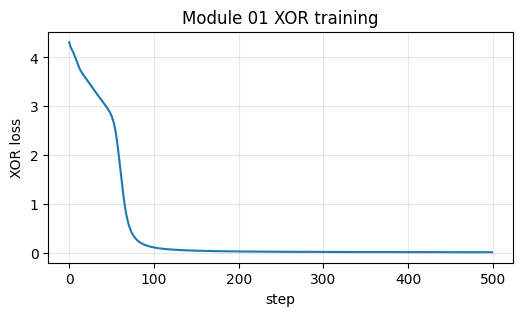

In [96]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("step")
plt.ylabel("XOR loss")
plt.title("Module 01 XOR training")
plt.grid(True, alpha=0.3);

## Exercise 5 — Topology Stress Test

Build expressions that reuse the same `Value` multiple times. This should catch backward implementations that overwrite gradients instead of accumulating them.

In [81]:
import math

stress_cases = [
    ("a*a + a", lambda a: a * a + a, lambda x: 2 * x + 1, 3.0),
   ("deep nesting", lambda a: a * 2 + a ** 3, lambda x: 2 + 3 * (x ** 2), 1.5),
    ("self power", lambda a: (a + 1).tanh() + (a**2).log(), lambda x: 1 - (math.tanh(x+1) ** 2) + 2 * x / (x**2), 2.5) 
]

for name, f, expected_grad, x_data in stress_cases:
    a = Value(x_data)
    out = f(a)
    out.backward()
    print(f"{name:>12}: grad={a.grad:.6f} expected={expected_grad(x_data):.6f}")

     a*a + a: grad=7.000000 expected=7.000000
deep nesting: grad=8.750000 expected=8.750000
  self power: grad=0.803641 expected=0.803641


## Submission Notes

In your Module 01 answer notes, you do not need to paste this whole notebook. Summarize:

- which cells you completed,
- the final XOR loss and predictions,
- any tests/checks you ran,
- any questions or uncertainty you want reviewed.